In [4]:
# !python.exe -m pip install --upgrade pip

In [2]:
# %pip install pandas numpy matplotlib MetaTrader5 hyperopt scipy 

In [ ]:
# import MetaTrader5 as mt5

# # Replace with your MT5 account details
# login = 7415336834  # Your MT5 account number
# password = "9o4OklPx@FUN7020"  # Your MT5 account password
# server = "Wealthway-Demo"  # Your broker's MT5 server address (e.g., "MetaQuotes-Demo")

# # Initialize the connection
# if not mt5.initialize():
#     print("initialize() failed, error code =", mt5.last_error())
#     mt5.shutdown()
#     quit()

# # Attempt to login
# authorized = mt5.login(login, password=password, server=server)
# if authorized:
#     print("Connected to MT5 account #", login)
#     # Your trading logic goes here
# else:
#     print("Failed to connect to MT5 account #", login, ", error code =", mt5.last_error())
#     mt5.shutdown()
#     quit()

# # Shut down the connection when done
# mt5.shutdown()

In [ ]:
import pandas as pd
import numpy as np

In [ ]:

def calculate_volume_imbalance(bid_volume: float, ask_volume: float) -> float:
    """
    Calculate the volume imbalance between bid and ask volumes.
    
    Parameters:
    -----------
    bid_volume : float
        Volume at the bid price
    ask_volume : float
        Volume at the ask price
        
    Returns:
    --------
    float
        Volume imbalance value
    """
    total_volume = bid_volume + ask_volume
    if total_volume == 0:
        return 0
    return (bid_volume - ask_volume) / total_volume

def compute_vib_bars(df: pd.DataFrame, threshold: float = 0.3) -> pd.DataFrame:
    """
    Compute Volume Imbalance Bars (VIBs) from tick data.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing tick data with columns:
        ['Timestamp', 'Bid price', 'Ask price', 'Bid volume', 'Ask volume']
    threshold : float, optional (default=0.3)
        Volume imbalance threshold to trigger a new bar
        
    Returns:
    --------
    pd.DataFrame
        DataFrame containing the VIB bars with columns:
        ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'num_ticks']
    """
    bars = []
    current_bar = {
        'timestamp': None,
        'open': None,
        'high': -np.inf,
        'low': np.inf,
        'volume': 0,
        'num_ticks': 0
    }
    
    cumulative_imbalance = 0
    
    for idx, row in df.iterrows():
        # Initialize bar if this is the first tick
        if current_bar['timestamp'] is None:
            current_bar['timestamp'] = row['Timestamp']
            current_bar['open'] = (row['Bid price'] + row['Ask price']) / 2
            
        # Update bar statistics
        mid_price = (row['Bid price'] + row['Ask price']) / 2
        current_bar['high'] = max(current_bar['high'], mid_price)
        current_bar['low'] = min(current_bar['low'], mid_price)
        current_bar['volume'] += row['Bid volume'] + row['Ask volume']
        current_bar['num_ticks'] += 1
        
        # Calculate imbalance
        tick_imbalance = calculate_volume_imbalance(row['Bid volume'], row['Ask volume'])
        cumulative_imbalance += tick_imbalance
        
        # Check if we should close the bar
        if abs(cumulative_imbalance) >= threshold:
            current_bar['close'] = mid_price
            bars.append(current_bar.copy())
            
            # Reset for next bar
            current_bar = {
                'timestamp': row['Timestamp'],
                'open': mid_price,
                'high': mid_price,
                'low': mid_price,
                'volume': 0,
                'num_ticks': 0
            }
            cumulative_imbalance = 0
    
    # Don't forget to add the last bar if it's not empty
    if current_bar['num_ticks'] > 0:
        current_bar['close'] = mid_price
        bars.append(current_bar)
    
    return pd.DataFrame(bars)

def analyze_vib_bars(bars_df: pd.DataFrame) -> dict:
    """
    Analyze the created VIB bars to get some basic statistics.
    
    Parameters:
    -----------
    bars_df : pd.DataFrame
        DataFrame containing the VIB bars
        
    Returns:
    --------
    dict
        Dictionary containing basic statistics about the bars
    """
    stats = {
        'total_bars': len(bars_df),
        'avg_ticks_per_bar': bars_df['num_ticks'].mean(),
        'avg_volume_per_bar': bars_df['volume'].mean(),
        'avg_price_range': (bars_df['high'] - bars_df['low']).mean(),
        'total_volume': bars_df['volume'].sum(),
        'total_ticks': bars_df['num_ticks'].sum()
    }
    return stats

# Example usage
if __name__ == "__main__":
    # Sample data
    data = {
        'Timestamp': pd.date_range(start='2024-01-01', periods=1000, freq='S'),
        'Bid price': np.random.normal(100, 0.1, 1000),
        'Ask price': np.random.normal(100.02, 0.1, 1000),
        'Bid volume': np.random.exponential(1000, 1000),
        'Ask volume': np.random.exponential(1000, 1000)
    }
    df = pd.DataFrame(data)
    
    # Compute VIB bars
    vib_bars = compute_vib_bars(df, threshold=0.3)
    
    # Analyze the bars
    statistics = analyze_vib_bars(vib_bars)
    print("VIB Statistics:")
    for key, value in statistics.items():
        print(f"{key}: {value:.2f}")

In [5]:
import numpy as np
from scipy import linalg

In [6]:
# Reservoir parameters
reservoir_size = 100  # Number of neurons in the reservoir
spectral_radius = 0.95 # Largest eigenvalue of the reservoir matrix (controls ESP)
input_scaling = 0.2  # Scaling factor for input weights
teacher_scaling = 0.5 # Scaling factor for teacher signal
teacher_shift = 0.1   # Shift for teacher signal
leak_rate = 0.7  # Leaking rate (for Leaky-Integrator neurons)

# Training parameters
training_length = 2000
testing_length = 500
initial_transient = 200 # Initial time steps to discard

In [7]:
# Generate the reservoir matrix
reservoir_matrix = np.random.rand(reservoir_size, reservoir_size) - 0.5
# Adjust the spectral radius
reservoir_matrix = reservoir_matrix * (spectral_radius / np.max(np.abs(np.linalg.eigvals(reservoir_matrix))))

In [8]:
# Generate input and teacher weights
input_weights = input_scaling * (np.random.rand(reservoir_size, 1) - 0.5)
# We won't initialize output_weights here because they are learned during training.

In [9]:
# XOR input data
input_data = np.random.randint(0, 2, size=(training_length + testing_length, 1))

# XOR teacher (target) signal
teacher_data = teacher_scaling * (np.logical_xor(input_data[:-1], input_data[1:]).astype(float)) + teacher_shift
teacher_data = teacher_data.reshape(-1, 1)

In [10]:
# Initialize the reservoir state
reservoir_state = np.zeros((reservoir_size, 1))

# Collect states during training
collected_states = np.zeros((training_length, reservoir_size))
for t in range(training_length + testing_length):
    input_value = input_data[t].reshape(1, 1)
    
    # Update the reservoir state (using Leaky-Integrator neurons)
    reservoir_state = (1 - leak_rate) * reservoir_state + leak_rate * np.tanh(
        np.dot(reservoir_matrix, reservoir_state) + np.dot(input_weights, input_value)
    )

    # Collect states after the initial transient
    if t >= initial_transient and t < training_length + initial_transient:
        collected_states[t - initial_transient] = reservoir_state.flatten()

In [11]:
# Train the output weights using Ridge Regression
output_weights = linalg.solve(
    collected_states.T @ collected_states + np.eye(reservoir_size) * 1e-8,
    collected_states.T @ teacher_data[:training_length],
).T

In [12]:
# Initialize an array to store the predicted outputs
predicted_output = np.zeros((testing_length, 1))

# Run the reservoir for the testing phase
for t in range(training_length, training_length + testing_length):
    input_value = input_data[t].reshape(1, 1)
    
    # Update reservoir state
    reservoir_state = (1 - leak_rate) * reservoir_state + leak_rate * np.tanh(
        np.dot(reservoir_matrix, reservoir_state) + np.dot(input_weights, input_value)
    )
    
    # Predict output
    predicted_output[t - training_length] = np.dot(output_weights, reservoir_state)

In [22]:
len(predicted_output[:-1])

499

Mean Squared Error: 0.06516158823092072


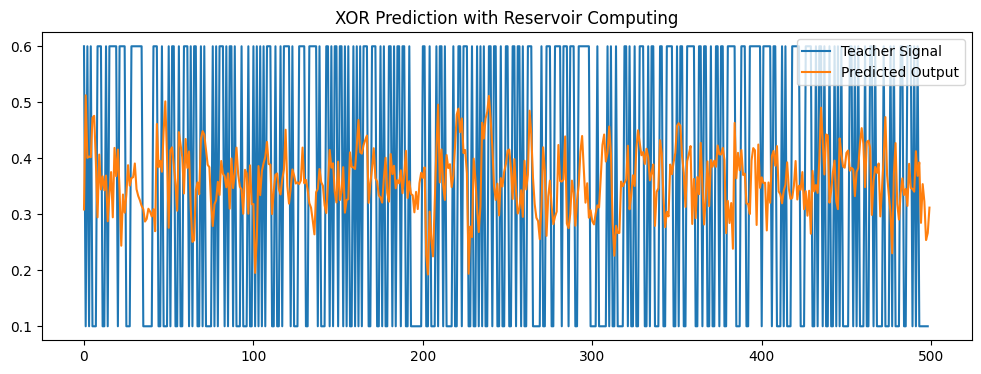

In [23]:
# Calculate Mean Squared Error (MSE)
mse = np.mean((predicted_output[:-1] - teacher_data[training_length:])**2)
print(f"Mean Squared Error: {mse}")

# (Optional) Plot results
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(teacher_data[training_length:], label="Teacher Signal")
plt.plot(predicted_output, label="Predicted Output")
plt.title("XOR Prediction with Reservoir Computing")
plt.legend()
plt.show()